# Cell 1 — Config & Mount Drive


In [ ]:

DATASET_NAME = 'AFDB'                          # 'AFDB' | 'LTAFDB' | 'CDB2017'
PARQUET_FILE = 'afdb_250hz_lead2_10s_5s.parquet'
FS_BASE      = 250                             # original Hz of dataset
# ══════════════════════════════════════════════════════════════

from google.colab import drive
drive.mount('/content/drive')

import os, sys, gc, time, warnings
import numpy as np, pandas as pd, torch
warnings.filterwarnings('ignore')

DEVICE  = 'cuda' if torch.cuda.is_available() else 'cpu'
CHUNK   = 512
N_FOLDS = 5

PROJECT_DIR  = '/content/drive/MyDrive/ECG project Amirhossein taleshi'
DATA_DIR     = os.path.join(PROJECT_DIR, 'processed_datasets')
OUT_DIR      = os.path.join(PROJECT_DIR, f'{DATASET_NAME}_benchmark')
CKPT_DIR     = os.path.join(PROJECT_DIR, 'checkpoints')
PARQUET_PATH = os.path.join(DATA_DIR, PARQUET_FILE)

os.makedirs(OUT_DIR,  exist_ok=True)
os.makedirs(CKPT_DIR, exist_ok=True)

MODEL_HZ = {
    'HuBERT-Small':100, 'HuBERT-Base':100, 'HuBERT-Large':100,
    'CLEF-Small':500,   'CLEF-Medium':500,  'CLEF-Large':500,
    'ST-MEM':250, 'ECG-JEPA':500, 'ECGFounder':500,
}

WIN_LEN = FS_BASE * 10   # samples per window

print(f'Dataset  : {DATASET_NAME}')
print(f'File     : {PARQUET_PATH}')
print(f'Base Hz  : {FS_BASE}  →  window = {WIN_LEN} samples')
print(f'Device   : {DEVICE.upper()}')
print(f'Output   : {OUT_DIR}')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset  : AFDB
File     : /content/drive/MyDrive/ECG project Amirhossein taleshi/processed_datasets/afdb_250hz_lead2_10s_5s.parquet
Base Hz  : 250  →  window = 2500 samples
Device   : CUDA
Output   : /content/drive/MyDrive/ECG project Amirhossein taleshi/AFDB_benchmark


# Cell 2 — Install & Clone All Repos


In [ ]:
os.system('pip install wfdb xgboost gdown timm einops huggingface_hub -q')

REPOS = {
    'ecg_jepa'            : 'https://github.com/sehunfromdaegu/ecg_jepa.git',
    'ST-MEM'              : 'https://github.com/vuno/ST-MEM.git',
    'ECGFounder'          : 'https://github.com/PKUDigitalHealth/ECGFounder.git',
    'ecg-foundation-model': 'https://github.com/Nokia-Bell-Labs/ecg-foundation-model.git',
}
for name, url in REPOS.items():
    if not os.path.exists(f'/content/{name}'):
        os.system(f'git clone -q {url} /content/{name}')
        print(f'Cloned : {name}')
    else:
        print(f'Ready  : {name}')

Ready  : ecg_jepa
Ready  : ST-MEM
Ready  : ECGFounder
Ready  : ecg-foundation-model


# Cell 3 — Download All Model Weights


In [ ]:
from huggingface_hub import hf_hub_download
import subprocess

CLEF_DIR = os.path.join(CKPT_DIR, 'clef')
os.makedirs(CLEF_DIR, exist_ok=True)

def cached_download(path, cmd, min_mb):
    if os.path.exists(path) and os.path.getsize(path) > min_mb * 1e6:
        print(f'  ✓ {os.path.basename(path)}'); return
    print(f'  ↓ {os.path.basename(path)} ...')
    os.system(cmd)
    mb = os.path.getsize(path)/1e6 if os.path.exists(path) else 0
    print(f'    {mb:.0f} MB')

# ECG-JEPA
cached_download(
    os.path.join(CKPT_DIR, 'ecgjepa.pth'),
    f'gdown 1gMOT4xjQQg0GZkY1iE6NuDzua4ALw00l -O "{CKPT_DIR}/ecgjepa.pth"', 50)

# ST-MEM
cached_download(
    os.path.join(CKPT_DIR, 'stmem.pth'),
    f'gdown "1E7J-A1HqWa2f08T6Sfk5uWk-_CFJhOYQ" -O "{CKPT_DIR}/stmem.pth"', 100)

# ECGFounder 1-lead
founder_ckpt = os.path.join(CKPT_DIR, '1_lead_ECGFounder.pth')
if not os.path.exists(founder_ckpt) or os.path.getsize(founder_ckpt) < 1e6:
    print('  ↓ 1_lead_ECGFounder.pth ...')
    cached = hf_hub_download(repo_id='PKUDigitalHealth/ECGFounder',
                              filename='1_lead_ECGFounder.pth')
    os.system(f'cp "{cached}" "{founder_ckpt}"')
    print(f'    {os.path.getsize(founder_ckpt)/1e6:.0f} MB')
else:
    print(f'  ✓ 1_lead_ECGFounder.pth')

# CLEF
CLEF_CKPTS = {
    'small' : ('clef_small.ckpt',  'https://zenodo.org/api/records/17572734/files/clef_small.ckpt/content'),
    'medium': ('clef_medium.ckpt', 'https://zenodo.org/api/records/17572734/files/clef_medium.ckpt/content'),
    'large' : ('clef_largel.ckpt', 'https://zenodo.org/api/records/17572734/files/clef_largel.ckpt/content'),
}
for size, (fname, url) in CLEF_CKPTS.items():
    path = os.path.join(CLEF_DIR, fname)
    cached_download(path, f'wget -q -O "{path}" "{url}"', 5)

print('\nAll weights ready.')

  ✓ ecgjepa.pth
  ✓ stmem.pth
  ✓ 1_lead_ECGFounder.pth
  ✓ clef_small.ckpt
  ✓ clef_medium.ckpt
  ✓ clef_largel.ckpt

All weights ready.


# Cell 4 — Load Dataset


In [ ]:
df       = pd.read_parquet(PARQUET_PATH)
segments = np.stack(df['signals'].values).astype(np.float32)
labels   = df['Labels'].values.astype(np.int64)
N        = len(segments)

# ── Extract recording IDs (CRITICAL for leak-free CV) ─────────────────────────
GROUP_COL = None
for col in ['record_name', 'recording', 'patient_id', 'filename',
            'record', 'file', 'subject', 'rec_id']:
    if col in df.columns:
        GROUP_COL = col
        break

if GROUP_COL:
    groups = df[GROUP_COL].values
    n_recs = len(np.unique(groups))
    print(f'  Group column : "{GROUP_COL}"  →  {n_recs} unique recordings')
else:
    # Fallback: AFDB has exactly 23 recordings; estimate boundaries
    # Windows are ordered by recording in typical AFDB parquets
    print('  WARNING: No recording-ID column found in parquet.')
    print('  Columns available:', df.columns.tolist())
    print('  Estimating groups from sequential ordering (23 AFDB recordings)...')
    N_RECS = 23
    sizes  = np.full(N_RECS, N // N_RECS, dtype=int)
    sizes[:N % N_RECS] += 1          # distribute remainder
    groups = np.repeat(np.arange(N_RECS), sizes)
    n_recs = N_RECS
    print(f'  Estimated {n_recs} groups from row ordering')

print(f'Windows  : {N:,}')
print(f'Signal   : {segments.shape[1]} samples = {segments.shape[1]/FS_BASE:.1f}s @ {FS_BASE} Hz')
print(f'AF       : {labels.sum():,}  ({labels.mean()*100:.1f}%)')
print(f'Normal   : {(labels==0).sum():,}  ({(labels==0).mean()*100:.1f}%)')
print(f'Leakage-safe GroupKFold will use {n_recs} recordings as groups')

  Columns available: ['record_id', 'signals', 'Labels']
  Estimating groups from sequential ordering (23 AFDB recordings)...
  Estimated 23 groups from row ordering
Windows  : 168,645
Signal   : 2500 samples = 10.0s @ 250 Hz
AF       : 68,406  (40.6%)
Normal   : 100,239  (59.4%)
Leakage-safe GroupKFold will use 23 recordings as groups


# Cell 5 — Helpers: Resample, CV, Efficiency

In [ ]:
from sklearn.model_selection import GroupKFold
from sklearn.metrics import roc_auc_score, f1_score, accuracy_score
from sklearn.preprocessing import StandardScaler
from scipy.signal import resample_poly, resample as sp_resample
from math import gcd
import xgboost as xgb
import numpy as np

# ── 5-Fold GROUP CV (recording-level — NO data leakage) ──────────────────────
N_FOLDS = 5
gkf     = GroupKFold(n_splits=N_FOLDS)
folds   = list(gkf.split(np.arange(N), labels, groups))

print(f'GroupKFold splits ({N_FOLDS} folds, split by recording):')
for i, (tr, te) in enumerate(folds):
    tr_recs = len(np.unique(groups[tr]))
    te_recs = len(np.unique(groups[te]))
    af_pct  = labels[te].mean() * 100
    print(f'  Fold {i+1}: train={len(tr):,} ({tr_recs} recs) | '
          f'test={len(te):,} ({te_recs} recs) | test AF={af_pct:.1f}%')

def run_cv(emb, labels, folds, name):
    aucs, f1s, accs, sens_list, spec_list = [], [], [], [], []
    all_preds_rows = []   # ← collect predictions from every fold

    for fold_i, (tr, te) in enumerate(folds):
        X_tr, X_te = emb[tr], emb[te]
        y_tr, y_te = labels[tr], labels[te]

        sc   = StandardScaler()
        X_tr = sc.fit_transform(X_tr)
        X_te = sc.transform(X_te)

        scale_pos = (y_tr == 0).sum() / max((y_tr == 1).sum(), 1)

        clf = xgb.XGBClassifier(
            n_estimators=300, max_depth=6, learning_rate=0.1,
            subsample=0.8, colsample_bytree=0.8,
            scale_pos_weight=scale_pos,
            eval_metric='auc', random_state=42, n_jobs=-1,
            device='cuda' if torch.cuda.is_available() else 'cpu',
        )
        clf.fit(X_tr, y_tr)

        probs = clf.predict_proba(X_te)[:, 1]
        preds = (probs >= 0.5).astype(int)

        auc  = roc_auc_score(y_te, probs)
        f1   = f1_score(y_te, preds, zero_division=0)
        acc  = accuracy_score(y_te, preds)
        tp   = ((preds==1)&(y_te==1)).sum()
        fn   = ((preds==0)&(y_te==1)).sum()
        tn   = ((preds==0)&(y_te==0)).sum()
        fp   = ((preds==1)&(y_te==0)).sum()
        sens = tp/(tp+fn) if (tp+fn)>0 else 0
        spec = tn/(tn+fp) if (tn+fp)>0 else 0

        aucs.append(auc); f1s.append(f1); accs.append(acc)
        sens_list.append(sens); spec_list.append(spec)

        # ── Save every test window's prediction ──────────────────
        for idx, wdx in enumerate(te):
            all_preds_rows.append({
                'window_idx'  : int(wdx),
                'fold'        : fold_i + 1,
                'true_label'  : int(y_te[idx]),
                'probability' : float(probs[idx]),
                'prediction'  : int(preds[idx]),
                'correct'     : int(preds[idx] == y_te[idx]),
            })

        print(f"  Fold {fold_i+1}/{N_FOLDS}  AUC={auc:.4f}  F1={f1:.4f}  "
              f"Acc={acc:.4f}  Sens={sens:.4f}  Spec={spec:.4f}")

    print(f"  ── MEAN  AUC={np.mean(aucs):.4f}±{np.std(aucs):.4f}  "
          f"F1={np.mean(f1s):.4f}±{np.std(f1s):.4f}  "
          f"Acc={np.mean(accs):.4f}±{np.std(accs):.4f}")

    return dict(
        model        = name,
        auc          = np.mean(aucs),    auc_std  = np.std(aucs),
        f1           = np.mean(f1s),     f1_std   = np.std(f1s),
        acc          = np.mean(accs),    acc_std  = np.std(accs),
        sens         = np.mean(sens_list),
        spec         = np.mean(spec_list),
        all_preds    = pd.DataFrame(all_preds_rows).sort_values('window_idx'),
    )

# ── Resampling ────────────────────────────────────────────────────────────────
def to_hz(batch, tgt_hz):
    if tgt_hz == FS_BASE:
        return batch.copy()
    g  = gcd(tgt_hz, FS_BASE)
    up = tgt_hz  // g
    dn = FS_BASE // g
    return np.stack([resample_poly(s, up, dn).astype(np.float32) for s in batch])

def to_n_samples(batch, n):
    return np.stack([sp_resample(s, n).astype(np.float32) for s in batch])

def pad_to_mult(x, m):
    r = x.shape[-1] % m
    if r == 0: return x
    return np.pad(x, [(0,0)]*(x.ndim-1) + [(0, m-r)])

# ── Batch embedder ────────────────────────────────────────────────────────────
def embed_all(embed_fn, model, data, name=''):
    out, n = [], len(data)
    for i in range(0, n, CHUNK):
        out.append(embed_fn(model, data[i:i+CHUNK]))
        done = min(i+CHUNK, n)
        if done % 10000 < CHUNK or done == n:
            print(f'    {name}: {done:,}/{n:,}')
    return np.concatenate(out)

# ── Efficiency ────────────────────────────────────────────────────────────────
def measure_efficiency(embed_fn, model, n_params, model_hz, n_runs=100):
    dummy = np.random.randn(1, WIN_LEN).astype(np.float32)
    for _ in range(5): embed_fn(model, dummy)
    if DEVICE=='cuda':
        torch.cuda.synchronize()
        torch.cuda.reset_peak_memory_stats()
    times = []
    for _ in range(n_runs):
        t0 = time.perf_counter()
        embed_fn(model, dummy)
        if DEVICE=='cuda': torch.cuda.synchronize()
        times.append((time.perf_counter()-t0)*1000)
    peak_mb = torch.cuda.max_memory_allocated()/1e6 if DEVICE=='cuda' else 0
    return dict(
        model         = '',
        params_M      = round(n_params/1e6, 1),
        ms_per_window = round(float(np.median(times)), 3),
        peak_gpu_mb   = round(peak_mb, 1),
        src_hz        = FS_BASE,
        model_hz      = model_hz,
        downsample    = round(FS_BASE/model_hz, 3),
    )

print('Helpers ready  (GroupKFold — recording-level, no leakage).')

GroupKFold splits (5 folds, split by recording):
  Fold 1: train=131,983 (18 recs) | test=36,662 (5 recs) | test AF=47.0%
  Fold 2: train=131,983 (18 recs) | test=36,662 (5 recs) | test AF=26.7%
  Fold 3: train=139,315 (19 recs) | test=29,330 (4 recs) | test AF=53.7%
  Fold 4: train=139,315 (19 recs) | test=29,330 (4 recs) | test AF=32.2%
  Fold 5: train=131,984 (18 recs) | test=36,661 (5 recs) | test AF=44.2%
Helpers ready  (GroupKFold — recording-level, no leakage).


# Cell 6 — All 9 Model Loaders & Embedders


In [ ]:
# ── HuBERT-ECG (100 Hz) ───────────────────────────────────────────────────────
def load_hubert(tag):
    from transformers import AutoModel
    return AutoModel.from_pretrained(
        f'Edoardo-BS/hubert-ecg-{tag}', trust_remote_code=True
    ).to(DEVICE).eval()

def embed_hubert(model, chunk):
    x    = torch.tensor(to_hz(chunk, 100), dtype=torch.float32, device=DEVICE)
    mask = torch.ones_like(x, dtype=torch.long)
    with torch.no_grad():
        h = model(x, attention_mask=mask).last_hidden_state
    return h.mean(1).cpu().float().numpy()

# ── CLEF (500 Hz) ─────────────────────────────────────────────────────────────
def load_clef(size):
    sys.path = [p for p in sys.path
                if 'ECGFounder' not in p and 'ST-MEM' not in p]
    for k in list(sys.modules):
        if 'clef' in k.lower(): del sys.modules[k]
    if '/content/ecg-foundation-model' not in sys.path:
        sys.path.insert(0, '/content/ecg-foundation-model')
    from clef.baselines.models.CLEF import create_net1d_by_size
    fname = {'small':'clef_small.ckpt',
             'medium':'clef_medium.ckpt',
             'large':'clef_largel.ckpt'}[size]
    return create_net1d_by_size(
        device=DEVICE, model_size=size, n_classes=None,
        linear_prob=False, pth=os.path.join(CKPT_DIR,'clef',fname),
        in_channels=1).eval()

def embed_clef(model, chunk):
    x = torch.tensor(to_hz(chunk, 500)[:,None,:],
                     dtype=torch.float32, device=DEVICE)
    with torch.no_grad():
        return model(x).cpu().float().numpy()

# ── ST-MEM (250 Hz) ───────────────────────────────────────────────────────────
_STMEM_SEQ = None   # computed once on load

def load_stmem():
    global _STMEM_SEQ
    sys.path = [p for p in sys.path if 'ECGFounder' not in p]
    for k in list(sys.modules):
        if 'models' in k: del sys.modules[k]
    if '/content/ST-MEM' not in sys.path:
        sys.path.insert(0, '/content/ST-MEM')
    from models import encoder as enc

    # ── Step 1: read checkpoint first to find the correct seq_len ─────────────
    state      = torch.load(os.path.join(CKPT_DIR,'stmem.pth'),
                            map_location='cpu', weights_only=False)
    state_dict = state.get('model', state)

    PATCH_SIZE = 75
    # pos_embedding shape: [1, n_patches + 2_extra_tokens, 768]
    # (ST-MEM ViT has 2 extra tokens: cls + temporal/distillation token)
    n_tokens   = state_dict['pos_embedding'].shape[1]  # e.g. 32
    N_EXTRA    = 2
    n_patches  = n_tokens - N_EXTRA                    # e.g. 30
    _STMEM_SEQ = n_patches * PATCH_SIZE                # e.g. 2250
    print(f'  ST-MEM: checkpoint has {n_tokens} tokens '
          f'({n_patches} patches × {PATCH_SIZE}) → seq_len={_STMEM_SEQ}')

    # ── Step 2: build model with seq_len that matches the checkpoint ───────────
    model = enc.st_mem_vit_base(
        num_leads=12, num_classes=None,
        seq_len=_STMEM_SEQ, patch_size=PATCH_SIZE
    ).to(DEVICE).eval()
    model.load_state_dict(state_dict, strict=False)
    return model

# ── ECG-JEPA (500 Hz) ─────────────────────────────────────────────────────────
def load_ecgjepa():
    sys.path = [p for p in sys.path if 'ST-MEM' not in p]
    for k in list(sys.modules):
        if 'models' in k: del sys.modules[k]
    if '/content/ecg_jepa' not in sys.path:
        sys.path.insert(0, '/content/ecg_jepa')
    from models import load_encoder
    enc, _ = load_encoder(ckpt_dir=os.path.join(CKPT_DIR, 'ecgjepa.pth'))
    return enc.to(DEVICE).eval()

def embed_ecgjepa(model, chunk):
    C      = int(model.c)
    P      = int(model.p)
    T      = int(model.t)
    T_need = P * T                       # total samples needed per lead
    x_rs   = to_n_samples(chunk, T_need) # resample to exactly P*T samples
    x_ml   = np.stack([x_rs]*C, axis=1) # replicate to C leads
    xt     = torch.tensor(
        x_ml.reshape(len(chunk), C, P, T),
        dtype=torch.float32, device=DEVICE)
    with torch.no_grad():
        h = model(xt)
    if isinstance(h, (tuple,list)): h = h[0]
    if h.ndim == 3: h = h.mean(1)
    return h.cpu().float().numpy()

# ── ECGFounder 1-lead (500 Hz) ────────────────────────────────────────────────
def load_ecgfounder():
    import torch.nn as nn
    sys.path = [p for p in sys.path if 'ST-MEM' not in p]
    for k in list(sys.modules):
        if 'net1d' in k: del sys.modules[k]
    if '/content/ECGFounder' not in sys.path:
        sys.path.append('/content/ECGFounder')
    from net1d import Net1D

    ckpt  = os.path.join(CKPT_DIR, '1_lead_ECGFounder.pth')
    state = torch.load(ckpt, map_location='cpu', weights_only=False)
    state = state.get('state_dict', state)
    n_cls = int(next(v for k,v in state.items()
                     if k.endswith('dense.weight')).shape[0])

    model = Net1D(
        in_channels=1, base_filters=64, ratio=1,
        filter_list=[64,160,160,400,400,1024,1024],
        m_blocks_list=[2,2,2,3,3,4,4],
        kernel_size=16, stride=2, groups_width=16,
        n_classes=n_cls, use_bn=True, use_do=True,
        return_features=True,
    ).to(DEVICE).eval()
    model.load_state_dict(state, strict=False)
    model.dense = nn.Identity()          # remove classification head
    return model

def embed_ecgfounder(model, chunk):
    FLEN = 5000
    x    = to_hz(chunk, 500)
    if x.shape[1] >= FLEN:
        x = x[:, :FLEN]
    else:
        pad = np.zeros((len(chunk), FLEN), dtype=np.float32)
        pad[:, :x.shape[1]] = x; x = pad
    xt = torch.tensor(x[:,None,:], dtype=torch.float32, device=DEVICE)
    with torch.no_grad():
        _, feats = model(xt)
    return feats.cpu().float().numpy()

print('All model functions ready.')

All model functions ready.


# Cell 7 — Run Full Benchmark


In [ ]:
ALL_RESULTS    = []
ALL_EFFICIENCY = []

MODELS = [
    ('HuBERT-Small', lambda: load_hubert('small'),  embed_hubert),
    ('HuBERT-Base',  lambda: load_hubert('base'),   embed_hubert),
    ('HuBERT-Large', lambda: load_hubert('large'),  embed_hubert),
    ('CLEF-Small',   lambda: load_clef('small'),    embed_clef),
    ('CLEF-Medium',  lambda: load_clef('medium'),   embed_clef),
    ('CLEF-Large',   lambda: load_clef('large'),    embed_clef),
    ('ST-MEM',       load_stmem,                    embed_stmem),
    ('ECG-JEPA',     load_ecgjepa,                  embed_ecgjepa),
    ('ECGFounder',   load_ecgfounder,               embed_ecgfounder),
]

for model_name, load_fn, embed_fn in MODELS:
    print(f'\n{"="*60}\n  {model_name}\n{"="*60}')

    res_csv = os.path.join(OUT_DIR, f'{model_name}_results.csv')
    emb_npy = os.path.join(OUT_DIR, f'{model_name}_embs.npy')

    # ── Resume support ────────────────────────────────────────
    if os.path.exists(res_csv) and os.path.getsize(res_csv) > 10:
        print('  Already done — loading from cache')
        r = pd.read_csv(res_csv).iloc[0].to_dict()
        r.update({'best_te':None,'best_probs':None,'best_preds':None})
        ALL_RESULTS.append(r)
        # reload efficiency if exists
        eff_csv = os.path.join(OUT_DIR, f'{model_name}_efficiency.csv')
        if os.path.exists(eff_csv):
            ALL_EFFICIENCY.append(pd.read_csv(eff_csv).iloc[0].to_dict())
        continue

    # ── Load model ────────────────────────────────────────────
    print('  Loading model ...')
    t0 = time.time()
    m  = load_fn()
    print(f'  Loaded in {time.time()-t0:.0f}s')
    n_params = sum(p.numel() for p in m.parameters())
    print(f'  Params: {n_params/1e6:.1f}M')

    # ── Efficiency ────────────────────────────────────────────
    print('  Measuring efficiency (100 runs) ...')
    eff           = measure_efficiency(embed_fn, m, n_params, MODEL_HZ[model_name])
    eff['model']  = model_name
    ALL_EFFICIENCY.append(eff)
    pd.DataFrame([eff]).to_csv(
        os.path.join(OUT_DIR, f'{model_name}_efficiency.csv'), index=False)
    print(f'  {eff["ms_per_window"]:.2f} ms/win | '
          f'GPU: {eff["peak_gpu_mb"]:.0f} MB | '
          f'src {FS_BASE}Hz→model {MODEL_HZ[model_name]}Hz')

    # ── Embed ─────────────────────────────────────────────────
    print(f'  Embedding {N:,} windows ...')
    emb = embed_all(embed_fn, m, segments, name=model_name)
    np.save(emb_npy, emb)
    print(f'  Shape: {emb.shape}')

    del m; gc.collect(); torch.cuda.empty_cache()

    # ── CV ────────────────────────────────────────────────────
    print(f'  Running {N_FOLDS}-fold CV ...')
    res = run_cv(emb, labels, folds, model_name)
    del emb; gc.collect()

      # ── Save per-model results CSV ─────────────────────────────────────────────
    row = {k:v for k,v in res.items() if k != 'all_preds'}
    pd.DataFrame([row]).to_csv(res_csv, index=False)

    # ── Save predictions CSV ───────────────────────────────────────────────────
    pred_csv = os.path.join(OUT_DIR, f'{model_name}_predictions.csv')
    res['all_preds'].to_csv(pred_csv, index=False)
    print(f'  Saved predictions: {os.path.basename(pred_csv)}  '
          f'({len(res["all_preds"]):,} rows)')

    ALL_RESULTS.append(res)



print('\n\n✓ All models complete.')


  HuBERT-Small
  Loading model ...


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

  Loaded in 1s
  Params: 30.5M
  Measuring efficiency (100 runs) ...
  7.02 ms/win | GPU: 490 MB | src 250Hz→model 100Hz
  Embedding 168,645 windows ...
    HuBERT-Small: 10,240/168,645
    HuBERT-Small: 20,480/168,645
    HuBERT-Small: 30,208/168,645
    HuBERT-Small: 40,448/168,645
    HuBERT-Small: 50,176/168,645
    HuBERT-Small: 60,416/168,645
    HuBERT-Small: 70,144/168,645
    HuBERT-Small: 80,384/168,645
    HuBERT-Small: 90,112/168,645
    HuBERT-Small: 100,352/168,645
    HuBERT-Small: 110,080/168,645
    HuBERT-Small: 120,320/168,645
    HuBERT-Small: 130,048/168,645
    HuBERT-Small: 140,288/168,645
    HuBERT-Small: 150,016/168,645
    HuBERT-Small: 160,256/168,645
    HuBERT-Small: 168,645/168,645
  Shape: (168645, 512)
  Running 5-fold CV ...
  Fold 1/5  AUC=0.9031  F1=0.7988  Acc=0.8117  Sens=0.7962  Spec=0.8254
  Fold 2/5  AUC=0.8800  F1=0.6728  Acc=0.8221  Sens=0.6854  Spec=0.8719
  Fold 3/5  AUC=0.9341  F1=0.8677  Acc=0.8681  Sens=0.8051  Spec=0.9413
  Fold 4/5  AUC

Loading weights:   0%|          | 0/212 [00:00<?, ?it/s]

  Loaded in 1s
  Params: 93.1M
  Measuring efficiency (100 runs) ...
  9.44 ms/win | GPU: 752 MB | src 250Hz→model 100Hz
  Embedding 168,645 windows ...
    HuBERT-Base: 10,240/168,645
    HuBERT-Base: 20,480/168,645
    HuBERT-Base: 30,208/168,645
    HuBERT-Base: 40,448/168,645
    HuBERT-Base: 50,176/168,645
    HuBERT-Base: 60,416/168,645
    HuBERT-Base: 70,144/168,645
    HuBERT-Base: 80,384/168,645
    HuBERT-Base: 90,112/168,645
    HuBERT-Base: 100,352/168,645
    HuBERT-Base: 110,080/168,645
    HuBERT-Base: 120,320/168,645
    HuBERT-Base: 130,048/168,645
    HuBERT-Base: 140,288/168,645
    HuBERT-Base: 150,016/168,645
    HuBERT-Base: 160,256/168,645
    HuBERT-Base: 168,645/168,645
  Shape: (168645, 768)
  Running 5-fold CV ...
  Fold 1/5  AUC=0.8900  F1=0.7904  Acc=0.7961  Sens=0.8186  Spec=0.7762
  Fold 2/5  AUC=0.8893  F1=0.6788  Acc=0.7970  Sens=0.8036  Spec=0.7946
  Fold 3/5  AUC=0.9407  F1=0.8797  Acc=0.8787  Sens=0.8254  Spec=0.9405
  Fold 4/5  AUC=0.9334  F1=0.792

Loading weights:   0%|          | 0/276 [00:00<?, ?it/s]

  Loaded in 1s
  Params: 188.6M
  Measuring efficiency (100 runs) ...
  12.23 ms/win | GPU: 1150 MB | src 250Hz→model 100Hz
  Embedding 168,645 windows ...
    HuBERT-Large: 10,240/168,645
    HuBERT-Large: 20,480/168,645
    HuBERT-Large: 30,208/168,645
    HuBERT-Large: 40,448/168,645
    HuBERT-Large: 50,176/168,645
    HuBERT-Large: 60,416/168,645
    HuBERT-Large: 70,144/168,645
    HuBERT-Large: 80,384/168,645
    HuBERT-Large: 90,112/168,645
    HuBERT-Large: 100,352/168,645
    HuBERT-Large: 110,080/168,645
    HuBERT-Large: 120,320/168,645
    HuBERT-Large: 130,048/168,645
    HuBERT-Large: 140,288/168,645
    HuBERT-Large: 150,016/168,645
    HuBERT-Large: 160,256/168,645
    HuBERT-Large: 168,645/168,645
  Shape: (168645, 960)
  Running 5-fold CV ...
  Fold 1/5  AUC=0.8647  F1=0.7701  Acc=0.7809  Sens=0.7814  Spec=0.7805
  Fold 2/5  AUC=0.7995  F1=0.6019  Acc=0.7711  Sens=0.6484  Spec=0.8157
  Fold 3/5  AUC=0.8920  F1=0.8517  Acc=0.8533  Sens=0.7840  Spec=0.9338
  Fold 4/5  

In [ ]:
# ── XGBoost Configuration Summary ─────────────────────────────────────────────
xgb_summary = pd.DataFrame([{
    'classifier'        : 'XGBoost (XGBClassifier)',
    'n_estimators'      : 300,
    'max_depth'         : 6,
    'learning_rate'     : 0.1,
    'subsample'         : 0.8,
    'colsample_bytree'  : 0.8,
    'scale_pos_weight'  : 'auto (class ratio per fold)',
    'eval_metric'       : 'auc',
    'threshold'         : 0.5,
    'random_state'      : 42,
    'cv_strategy'       : 'GroupKFold (5-fold, split by recording)',
    'n_folds'           : 5,
    'n_recordings'      : len(np.unique(groups)),
    'scaler'            : 'StandardScaler (fit on train, applied to test)',
    'device'            : 'cuda' if torch.cuda.is_available() else 'cpu',
    'dataset'           : DATASET_NAME,
    'window_sec'        : 10,
    'overlap_sec'       : 5,
    'fs_hz'             : FS_BASE,
    'n_windows_total'   : N,
}])

xgb_csv = os.path.join(OUT_DIR, f'{DATASET_NAME}_xgboost_config.csv')
xgb_summary.to_csv(xgb_csv, index=False)
print('XGBoost Configuration Summary:')
print(xgb_summary.T.to_string(header=False))
print(f'\nSaved: {xgb_csv}')

XGBoost Configuration Summary:
classifier                               XGBoost (XGBClassifier)
n_estimators                                                 300
max_depth                                                      6
learning_rate                                                0.1
subsample                                                    0.8
colsample_bytree                                             0.8
scale_pos_weight                     auto (class ratio per fold)
eval_metric                                                  auc
threshold                                                    0.5
random_state                                                  42
cv_strategy              GroupKFold (5-fold, split by recording)
n_folds                                                        5
n_recordings                                                  23
scaler            StandardScaler (fit on train, applied to test)
device                                                     

In [31]:
# ── Combine all model predictions into one file ───────────────────────────────
all_model_preds = []

for model_name, _, _ in MODELS:
    pred_csv = os.path.join(OUT_DIR, f'{model_name}_predictions.csv')
    if os.path.exists(pred_csv):
        df_pred = pd.read_csv(pred_csv)
        df_pred.insert(0, 'model', model_name)   # add model name column
        all_model_preds.append(df_pred)
        print(f'  Loaded: {model_name}  ({len(df_pred):,} rows)')
    else:
        print(f'  Missing: {model_name} — no predictions CSV found')

if all_model_preds:
    combined = pd.concat(all_model_preds, ignore_index=True)
    combined_path = os.path.join(OUT_DIR, f'{DATASET_NAME}_all_predictions.csv')
    combined.to_csv(combined_path, index=False)
    print(f'\nCombined: {len(combined):,} total rows')
    print(f'Saved   : {combined_path}')
    print(f'\nColumns : {list(combined.columns)}')
    print(combined.groupby('model')[['correct']].mean().round(4).rename(
          columns={'correct':'accuracy'}).to_string())

  Loaded: HuBERT-Small  (168,645 rows)
  Loaded: HuBERT-Base  (168,645 rows)
  Loaded: HuBERT-Large  (168,645 rows)
  Loaded: CLEF-Small  (168,645 rows)
  Loaded: CLEF-Medium  (168,645 rows)
  Loaded: CLEF-Large  (168,645 rows)
  Loaded: ST-MEM  (168,645 rows)
  Loaded: ECG-JEPA  (168,645 rows)
  Loaded: ECGFounder  (168,645 rows)

Combined: 1,517,805 total rows
Saved   : /content/drive/MyDrive/ECG project Amirhossein taleshi/AFDB_benchmark/AFDB_all_predictions.csv

Columns : ['model', 'window_idx', 'fold', 'true_label', 'probability', 'prediction', 'correct']
              accuracy
model                 
CLEF-Large      0.8335
CLEF-Medium     0.8616
CLEF-Small      0.8016
ECG-JEPA        0.9324
ECGFounder      0.9828
HuBERT-Base     0.8057
HuBERT-Large    0.7643
HuBERT-Small    0.8025
ST-MEM          0.9234


# Cell 8 — Summary Tables


In [32]:
# ── Performance summary ───────────────────────────────────────────────────────
rows = []
for r in ALL_RESULTS:
    rows.append({
        'Model'      : r['model'],
        'AUC'        : f"{r['auc']:.4f}±{r['auc_std']:.4f}",
        'F1'         : f"{r['f1']:.4f}±{r['f1_std']:.4f}",
        'Accuracy'   : f"{r['acc']:.4f}±{r['acc_std']:.4f}",
        'Sensitivity': f"{r['sens']:.4f}",
        'Specificity': f"{r['spec']:.4f}",
        '_auc'       : r['auc'],
    })
df_summary = (pd.DataFrame(rows)
              .sort_values('_auc', ascending=False)
              .drop('_auc', axis=1)
              .reset_index(drop=True))
df_summary.insert(0, 'Rank', range(1, len(df_summary)+1))

summary_csv = os.path.join(OUT_DIR, f'{DATASET_NAME}_summary.csv')
df_summary.to_csv(summary_csv, index=False)
print(df_summary.to_string(index=False))

# ── Efficiency summary ────────────────────────────────────────────────────────
if ALL_EFFICIENCY:
    df_eff = pd.DataFrame(ALL_EFFICIENCY)[
        ['model','params_M','src_hz','model_hz',
         'downsample','ms_per_window','peak_gpu_mb']]
    eff_csv = os.path.join(OUT_DIR, f'{DATASET_NAME}_efficiency.csv')
    df_eff.to_csv(eff_csv, index=False)
    print('\n' + df_eff.to_string(index=False))

 Rank        Model           AUC            F1      Accuracy Sensitivity Specificity
    1   ECGFounder 0.9968±0.0027 0.9787±0.0088 0.9833±0.0071      0.9704      0.9911
    2     ECG-JEPA 0.9860±0.0101 0.9146±0.0649 0.9367±0.0484      0.9103      0.9557
    3       ST-MEM 0.9776±0.0149 0.8959±0.0685 0.9263±0.0468      0.8774      0.9574
    4   CLEF-Large 0.9250±0.0484 0.7977±0.0884 0.8356±0.0646      0.8500      0.8179
    5  CLEF-Medium 0.9148±0.0942 0.8188±0.0918 0.8664±0.0638      0.8233      0.8867
    6  HuBERT-Base 0.8986±0.0365 0.7585±0.0835 0.8106±0.0530      0.7775      0.8415
    7 HuBERT-Small 0.8755±0.0565 0.7375±0.0963 0.8066±0.0609      0.7128      0.8697
    8   CLEF-Small 0.8414±0.1470 0.7004±0.2201 0.8093±0.0904      0.6638      0.8884
    9 HuBERT-Large 0.8328±0.0629 0.6776±0.1451 0.7699±0.0761      0.6614      0.8475

       model  params_M  src_hz  model_hz  downsample  ms_per_window  peak_gpu_mb
HuBERT-Small      30.5     250       100         2.5          7.022 

# Cell 9 — Visualizations


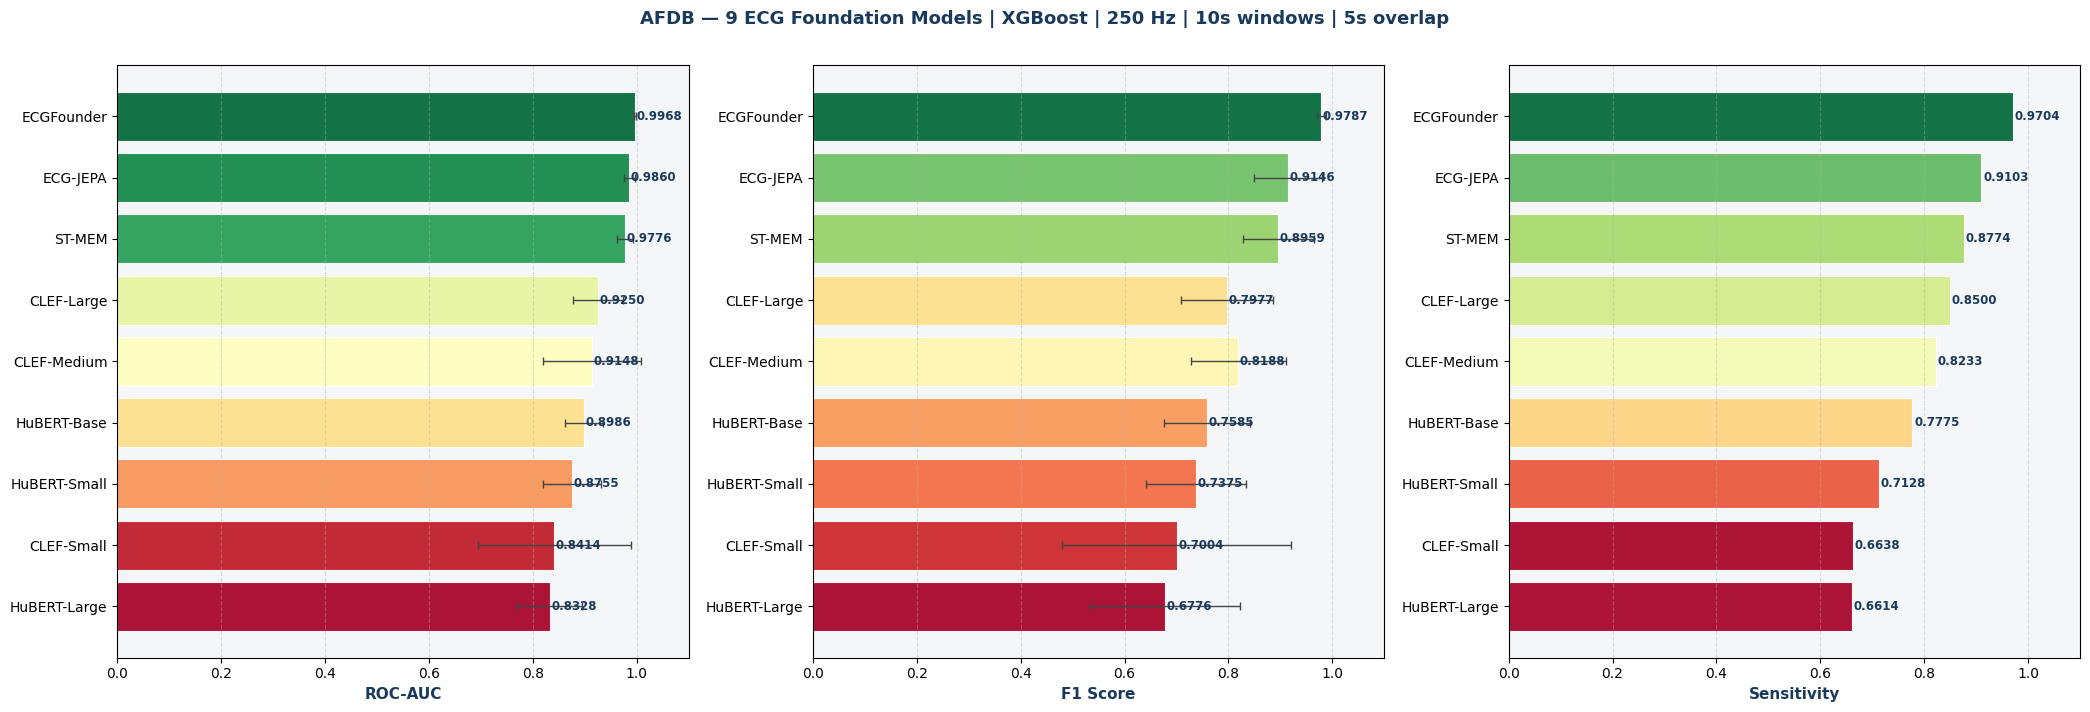

Saved: /content/drive/MyDrive/ECG project Amirhossein taleshi/AFDB_benchmark/AFDB_comparison_chart.png
  t-SNE: HuBERT-Small ...
  t-SNE: HuBERT-Base ...
  t-SNE: HuBERT-Large ...
  t-SNE: CLEF-Small ...
  t-SNE: CLEF-Medium ...
  t-SNE: CLEF-Large ...
  t-SNE: ST-MEM ...
  t-SNE: ECG-JEPA ...
  t-SNE: ECGFounder ...
Saved: /content/drive/MyDrive/ECG project Amirhossein taleshi/AFDB_benchmark/AFDB_tsne_all_models.png


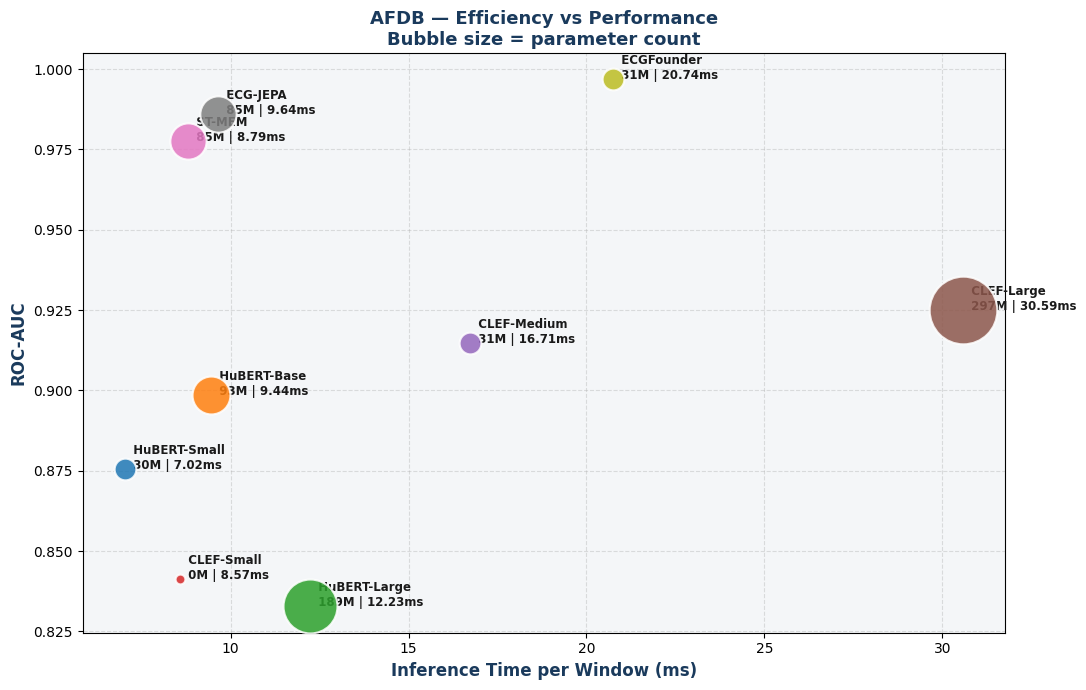

Saved: /content/drive/MyDrive/ECG project Amirhossein taleshi/AFDB_benchmark/AFDB_efficiency_plot.png


In [33]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
from PIL import Image

TC = '#1A3A5C'

def score_colors(vals):
    norm = plt.Normalize(min(vals), max(vals))
    return [mcolors.to_hex(plt.cm.RdYlGn(norm(v))) for v in vals]

df_p = pd.DataFrame([{k:v for k,v in r.items()
                       if k not in ('best_te','best_probs','best_preds')}
                      for r in ALL_RESULTS]).sort_values('auc', ascending=False)

# ── 1. Comparison bar chart ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(21, 7))
fig.patch.set_facecolor('white')
fig.suptitle(f'{DATASET_NAME} — 9 ECG Foundation Models | '
             f'XGBoost | {FS_BASE} Hz | 10s windows | 5s overlap',
             fontsize=13, fontweight='bold', color=TC, y=1.01)

for ax, (met, err, lbl) in zip(axes, [
    ('auc','auc_std','ROC-AUC'),
    ('f1', 'f1_std', 'F1 Score'),
    ('sens',  None,  'Sensitivity'),
]):
    vals = df_p[met].tolist()
    ax.set_facecolor('#F4F6F8')
    bars = ax.barh(df_p['model'], vals,
                   color=score_colors(vals),
                   edgecolor='white', linewidth=0.8, alpha=0.92)
    if err and err in df_p.columns:
        ax.errorbar(vals, df_p['model'],
                    xerr=df_p[err].tolist(),
                    fmt='none', color='#444', capsize=3, lw=1)
    for bar, v in zip(bars, vals):
        ax.text(v+0.003, bar.get_y()+bar.get_height()/2,
                f'{v:.4f}', va='center', fontsize=8.5,
                fontweight='bold', color=TC)
    ax.set_xlabel(lbl, fontsize=11, fontweight='bold', color=TC)
    ax.set_xlim(0, 1.1)
    ax.grid(axis='x', linestyle='--', alpha=0.4)
    ax.invert_yaxis()

plt.tight_layout()
chart_path = os.path.join(OUT_DIR, f'{DATASET_NAME}_comparison_chart.png')
plt.savefig(chart_path, dpi=180, bbox_inches='tight', facecolor='white')
plt.show(); plt.close(); print(f'Saved: {chart_path}')

# ── 2. t-SNE 3×3 grid ────────────────────────────────────────────────────────
np.random.seed(42)
n_each  = min(1500, (labels==1).sum(), (labels==0).sum())
sub_idx = np.concatenate([
    np.random.choice(np.where(labels==1)[0], n_each, replace=False),
    np.random.choice(np.where(labels==0)[0], n_each, replace=False),
])
np.random.shuffle(sub_idx)
sub_lbl = labels[sub_idx]

tsne_imgs = []
for r in ALL_RESULTS:
    name = r['model']
    npy  = os.path.join(OUT_DIR, f'{name}_embs.npy')
    if not os.path.exists(npy):
        print(f'  Skip t-SNE {name} — no cache'); continue

    print(f'  t-SNE: {name} ...')
    emb  = StandardScaler().fit_transform(np.load(npy)[sub_idx])
    proj = TSNE(n_components=2, perplexity=40, n_iter=1000,
                random_state=42, n_jobs=-1).fit_transform(emb)

    fig, ax = plt.subplots(figsize=(5.5, 5))
    fig.patch.set_facecolor('white'); ax.set_facecolor('#F4F6F8')
    for lv, clr, ln in [(0,'#2980B9','Normal'),(1,'#E74C3C','AF')]:
        m = sub_lbl==lv
        ax.scatter(proj[m,0], proj[m,1],
                   c=clr, label=ln, s=5, alpha=0.5, linewidths=0)
    ax.set_title(f'{name}\nAUC={r["auc"]:.4f}  F1={r["f1"]:.4f}',
                 fontsize=10, fontweight='bold', color=TC)
    ax.legend(fontsize=8, markerscale=3)
    ax.set_xticks([]); ax.set_yticks([])
    plt.tight_layout()
    tmp = os.path.join(OUT_DIR, f'_tsne_{name}.png')
    plt.savefig(tmp, dpi=120, bbox_inches='tight', facecolor='white')
    plt.close(); tsne_imgs.append(tmp)
    del emb, proj; gc.collect()

# stitch 3×3
if len(tsne_imgs) >= 2:
    imgs  = [Image.open(p) for p in tsne_imgs]
    W, H  = imgs[0].size
    nc = 3; nr = (len(imgs)+2)//3
    grid = Image.new('RGB', (W*nc, H*nr), (255,255,255))
    for i, im in enumerate(imgs):
        grid.paste(im, ((i%nc)*W, (i//nc)*H))
    tsne_path = os.path.join(OUT_DIR, f'{DATASET_NAME}_tsne_all_models.png')
    grid.save(tsne_path); print(f'Saved: {tsne_path}')
    # clean up temp files
    for p in tsne_imgs: os.remove(p)

# ── 3. Efficiency scatter ─────────────────────────────────────────────────────
if ALL_EFFICIENCY:
    auc_map = {r['model']:r['auc'] for r in ALL_RESULTS}
    df_e    = pd.DataFrame(ALL_EFFICIENCY)
    df_e['auc'] = df_e['model'].map(auc_map)

    fig, ax = plt.subplots(figsize=(11, 7))
    fig.patch.set_facecolor('white'); ax.set_facecolor('#F4F6F8')
    for _, row in df_e.iterrows():
        ax.scatter(row['ms_per_window'], row['auc'],
                   s=max(row['params_M']*8, 50),
                   alpha=0.85, edgecolors='white', linewidths=1.5, zorder=5)
        ax.annotate(
            f"  {row['model']}\n"
            f"  {row['params_M']:.0f}M | {row['ms_per_window']:.2f}ms",
            (row['ms_per_window'], row['auc']),
            fontsize=8.5, fontweight='bold', color='#1A1A1A')
    ax.set_xlabel('Inference Time per Window (ms)',
                  fontsize=12, fontweight='bold', color=TC)
    ax.set_ylabel('ROC-AUC',
                  fontsize=12, fontweight='bold', color=TC)
    ax.set_title(f'{DATASET_NAME} — Efficiency vs Performance\n'
                 'Bubble size = parameter count',
                 fontsize=13, fontweight='bold', color=TC)
    ax.grid(linestyle='--', alpha=0.4)
    plt.tight_layout()
    eff_plot = os.path.join(OUT_DIR, f'{DATASET_NAME}_efficiency_plot.png')
    plt.savefig(eff_plot, dpi=180, bbox_inches='tight', facecolor='white')
    plt.show(); plt.close(); print(f'Saved: {eff_plot}')

# Cell 10 — Save ZIP & Download


In [38]:
# ── Re-run CV + save predictions for models missing prediction CSV (AFDB) ──────
MISSING = []
for model_name, _, _ in MODELS:
    pred_csv = os.path.join(OUT_DIR, f'{model_name}_predictions.csv')
    emb_npy  = os.path.join(OUT_DIR, f'{model_name}_embs.npy')
    if not os.path.exists(pred_csv) and os.path.exists(emb_npy):
        MISSING.append(model_name)

print(f'Models missing predictions: {MISSING}')

for model_name, _, _ in MODELS:
    if model_name not in MISSING:
        continue

    emb_npy = os.path.join(OUT_DIR, f'{model_name}_embs.npy')
    print(f'\n{"="*60}\n  {model_name} — rerunning CV only\n{"="*60}')

    emb = np.load(emb_npy)
    print(f'  Loaded embeddings: {emb.shape}')

    res = run_cv(emb, labels, folds, model_name)
    del emb; gc.collect()

    pred_csv = os.path.join(OUT_DIR, f'{model_name}_predictions.csv')
    res['all_preds'].to_csv(pred_csv, index=False)
    print(f'  Saved: {os.path.basename(pred_csv)}  ({len(res["all_preds"]):,} rows)')

print('\nDone.')

Models missing predictions: []

Done.


In [39]:
# ── Combine all model predictions into one file (AFDB) ────────────────────────
all_model_preds = []

for model_name, _, _ in MODELS:
    pred_csv = os.path.join(OUT_DIR, f'{model_name}_predictions.csv')
    if os.path.exists(pred_csv):
        df_pred = pd.read_csv(pred_csv)
        df_pred.insert(0, 'model', model_name)
        all_model_preds.append(df_pred)
        print(f'  ✓ {model_name:<15} {len(df_pred):,} rows')
    else:
        print(f'  ✗ {model_name:<15} STILL MISSING')

if all_model_preds:
    combined = pd.concat(all_model_preds, ignore_index=True)
    combined_path = os.path.join(OUT_DIR, f'{DATASET_NAME}_all_predictions.csv')
    combined.to_csv(combined_path, index=False)
    print(f'\nCombined : {len(combined):,} total rows')
    print(f'Models   : {combined["model"].nunique()}/9')
    print(f'Saved    : {combined_path}')

  ✓ HuBERT-Small    168,645 rows
  ✓ HuBERT-Base     168,645 rows
  ✓ HuBERT-Large    168,645 rows
  ✓ CLEF-Small      168,645 rows
  ✓ CLEF-Medium     168,645 rows
  ✓ CLEF-Large      168,645 rows
  ✓ ST-MEM          168,645 rows
  ✓ ECG-JEPA        168,645 rows
  ✓ ECGFounder      168,645 rows

Combined : 1,517,805 total rows
Models   : 9/9
Saved    : /content/drive/MyDrive/ECG project Amirhossein taleshi/AFDB_benchmark/AFDB_all_predictions.csv


In [40]:
import zipfile
from google.colab import files

zip_path = os.path.join(OUT_DIR, f'{DATASET_NAME}_full_results.zip')

with zipfile.ZipFile(zip_path, 'w', zipfile.ZIP_DEFLATED) as zf:
    for fname in sorted(os.listdir(OUT_DIR)):
        if fname.endswith(('.csv', '.png')):   # skip large .npy files
            fpath = os.path.join(OUT_DIR, fname)
            zf.write(fpath, fname)

print(f'ZIP contents ({DATASET_NAME}):')
with zipfile.ZipFile(zip_path) as zf:
    for info in zf.infolist():
        print(f'  {info.filename:<50} {info.file_size/1024:>7.1f} KB')

print(f'\nAll files on Drive: {OUT_DIR}')
files.download(zip_path)

ZIP contents (AFDB):
  AFDB_all_predictions.csv                           65996.3 KB
  AFDB_comparison_chart.png                            161.7 KB
  AFDB_efficiency.csv                                    0.4 KB
  AFDB_efficiency_plot.png                             149.1 KB
  AFDB_summary.csv                                       0.7 KB
  AFDB_tsne_all_models.png                             635.7 KB
  AFDB_xgboost_config.csv                                0.4 KB
  CLEF-Large_efficiency.csv                              0.1 KB
  CLEF-Large_predictions.csv                          5665.5 KB
  CLEF-Large_results.csv                                 0.2 KB
  CLEF-Medium_efficiency.csv                             0.1 KB
  CLEF-Medium_predictions.csv                         5689.1 KB
  CLEF-Medium_results.csv                                0.2 KB
  CLEF-Small_efficiency.csv                              0.1 KB
  CLEF-Small_predictions.csv                          5652.9 KB
  CLEF-Small_result

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>